# Ridge Regression from Scratch 📏

In this notebook, we extend Linear Regression by adding **L2 Regularization**, creating **Ridge Regression**.

## 📖 Theoretical Background

Regularization discourages the learning of a more complex or flexible model, reducing the risk of overfitting.

### 1. The Cost Function
We add a penalty term proportional to the square of the magnitude of the coefficients:
$$J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2 + \frac{\lambda}{2} \sum_{j=1}^{n} w_j^2$$
Note: We do not penalize the bias term $b$.

### 2. The Gradients
The gradients change slightly to include the derivative of the penalty term:
$$\frac{\partial J}{\partial w} = \frac{1}{m} X^T(\hat{y} - y) + \lambda w$$
$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum(\hat{y} - y)$$

This shrinks the weights towards zero, preventing any single feature from dominating.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

np.random.seed(42)

## 🏗️ The Implementation

In [2]:
class RidgeRegression:
    def __init__(self, learning_rate=0.01, lambda_param=1.0, n_iterations=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iterations = n_iterations
        self.w = None
        self.b = None
        self.loss_history = []
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        
        for _ in range(self.n_iterations):
            y_predicted = np.dot(X, self.w) + self.b
            
            # Compute loss
            mse = (1 / (2 * n_samples)) * np.sum((y_predicted - y) ** 2)
            l2_penalty = (self.lambda_param / 2) * np.sum(self.w ** 2)
            self.loss_history.append(mse + l2_penalty)
            
            # Compute gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y)) + self.lambda_param * self.w
            db = (1 / n_samples) * np.sum(y_predicted - y)
            
            # Update weights
            self.w -= self.lr * dw
            self.b -= self.lr * db
            
    def predict(self, X):
        return np.dot(X, self.w) + self.b

## 🧪 Data Generation and Training
We train two models with different lambdas to see the shrinkage.

In [3]:
X, y = make_regression(n_samples=200, n_features=1, noise=20, random_state=42)

# Lambda = 0 is essentially standard Linear Regression
ridge_weak = RidgeRegression(learning_rate=0.1, lambda_param=0, n_iterations=1000)
ridge_weak.fit(X, y)

# High lambda will penalize weights heavily
ridge_strong = RidgeRegression(learning_rate=0.1, lambda_param=2.0, n_iterations=1000)
ridge_strong.fit(X, y)

print(f"Weight with lambda=0: {ridge_weak.w[0]:.4f}")
print(f"Weight with lambda=2: {ridge_strong.w[0]:.4f}")

Weight with lambda=0: 86.9955
Weight with lambda=2: 26.2112


## 📊 Visualization

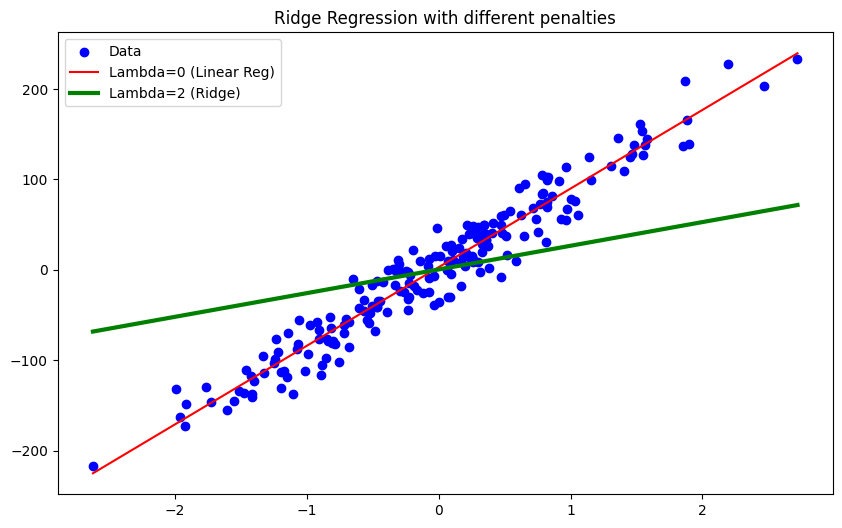

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color="blue", label="Data")

line_X = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
plt.plot(line_X, ridge_weak.predict(line_X), color="red", label="Lambda=0 (Linear Reg)")
plt.plot(line_X, ridge_strong.predict(line_X), color="green", linewidth=3, label="Lambda=2 (Ridge)")

plt.title("Ridge Regression with different penalties")
plt.legend()
plt.show()

## 📊 Additional Visualizations

In [ ]:

# 1. Ridge Coefficients Path
alphas = np.logspace(-2, 4, 20)
coefs = []
for a in alphas:
    temp_model = RidgeRegression(alpha=a)
    temp_model.fit(X, y)
    coefs.append(temp_model.weights)

plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Weights')
plt.title('Ridge Coefficients as a function of regularization')
plt.show()
